In [245]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
import causalpy as cp
import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random

In [4]:
myPredictorsDf = pd.read_csv('../predictorsDf.csv')

In [ ]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myYValue = myPredictorsDf['CPC12']
X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.30)

In [6]:
myGridSearchCv = gridSearchKFoldRegression(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='r2')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), 'clf__max_depth': 2, 'clf__n_estimators': 10}
Best cross val r2 score: 0.1129
R2 score  on test set: 0.1346627773476523


In [17]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': LogisticRegression(), 'clf__C': 0.1}
Best cross val roc_auc score: 0.8290
Area under the receiver operating curve on test set is 0.9023
Accuracy score on test set is 0.9316


C:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


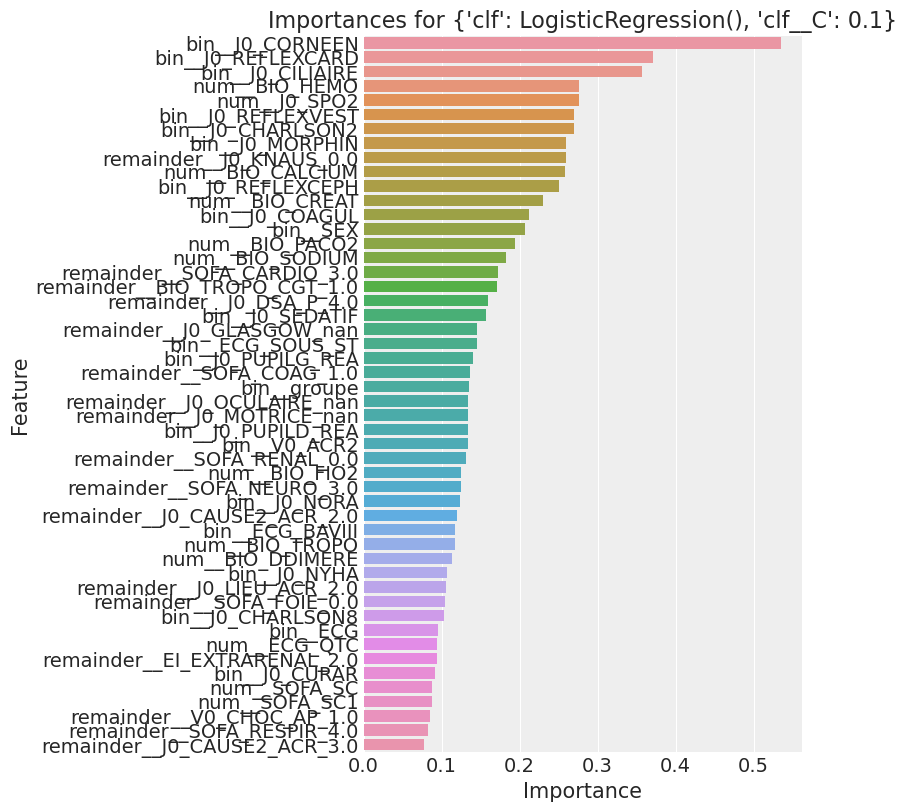

In [18]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps['preprocessor'].get_feature_names_out()), X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.231801
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.231046
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.5586946360008938
p-value: 0.7562771889139482
Degress of freedom: 2.0


C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
C:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_catego

0.7562771889139482

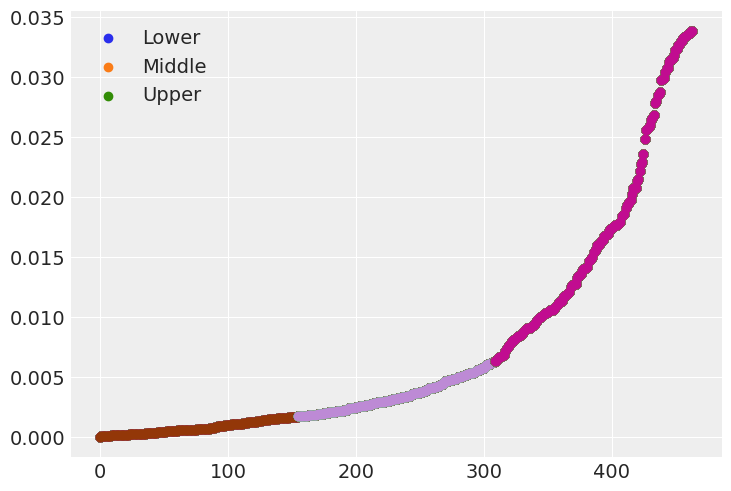

In [20]:
getTreatmentEffectDiff(X_train, y_train, myBestModel)

In [238]:
def getTreatmentEffectDiffUnsupervised(aX, aY, aModel):
    if hasattr(aModel, 'predict'):
        aModel.fit(aX)
        myGroups = aModel.predict(aX)
    elif hasattr(aModel, 'fit_predict'):
        myGroups = aModel.fit_predict(aX)
    else:
        print(f'Model prediction output not supported')
    myNewDf = pd.DataFrame()
    myNewDf['predicted_effect_group'] = myGroups
    myData = pd.concat([aX['groupe'], myNewDf['predicted_effect_group'], aY], axis=1)
    model1 = smf.logit(
    'CPC12 ~ predicted_effect_group + groupe',
    data=myData
    ).fit()

    model2 = smf.logit(
    'CPC12 ~ predicted_effect_group * groupe',
    data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    return p_value, model2, myData

def plotPredictedEffectDiff(aData, aBestModel):
    predicted_effect_groups = aData['predicted_effect_group'].unique()
    predicted_effect_groups.sort()
    groupe_values = aData['groupe'].unique()
    groupe_values.sort()
    groupe_values = list(filter(lambda x: not np.isnan(x), groupe_values))
    
    predicted_effect_groups = list(filter(lambda x: not np.isnan(x), predicted_effect_groups))

    # Prepare the DataFrame for prediction
    predictions = []
    for groupe in groupe_values:
        for effect in predicted_effect_groups:
            temp_df = pd.DataFrame({
                'predicted_effect_group': [effect],
                'groupe': [groupe]
            })
            # Predict the probability
            temp_df['predicted_prob'] = aBestModel.predict(temp_df)
            predictions.append(temp_df)

    # Concatenate all predictions
    predictions_df = pd.concat(predictions)

    # Create a bar plot
    plt.figure(figsize=(8, 6))
    for i, groupe in enumerate(groupe_values):
        subset = predictions_df[predictions_df['groupe'] == groupe]
        plt.bar(
            subset['predicted_effect_group'] + (i * 0.2) - 0.1,  # Shift bars slightly for better visualization
            subset['predicted_prob'],
            width=0.2,
            label=f'Groupe {groupe}'
        )
        
    x_positions = np.arange(len(predicted_effect_groups)) 

    plt.xticks(x_positions)
    plt.xlabel('Predicted Effect Group')
    plt.ylabel('Predicted Probability of CPC12')
    plt.title('Predicted Probability of CPC12 by Predicted Effect Group and Groupe')
    plt.legend(title='Groupe')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [251]:
myBestModel = None
myBestPValue = 1
myBestData = None
myBestKMeans = None
myDroppedColumns = None
myRemainingColumns = None
myNumDroppedColumns = 0

for i in range(200):
    myNumColumsToDrop = random.randint(1, 140)
    myNewXValue = X_train.copy()
    myNewXValue = myNewXValue.drop(columns=['groupe'])
    myColumnsToDrop = myNewXValue.sample(n=myNumColumsToDrop, axis=1).columns
    myNewXValue.drop(columns = myColumnsToDrop, inplace=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = myNewXValue)
    myPipelineSteps.append(('clf', AgglomerativeClustering(n_clusters=random.randint(2, 7))))
    myPipeline = Pipeline(myPipelineSteps)
    try:
        p_value, myModel, myData = getTreatmentEffectDiffUnsupervised(X_train, y_train, myPipeline) 
        if p_value < myBestPValue:
            myBestPValue = p_value
            myBestModel = myModel
            myBestData = myData
            myBestKMeans = myPipeline
            myRemainingColumns = myNewXValue.columns
            myDroppedColumns = myColumnsToDrop
            myNumDroppedColumns = myNumColumsToDrop
    except:
        print('Failed')
        continue

# p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(X_test, y_test, myBestKMeans)
# plotPredictedEffectDiff(aData = myData, aBestModel = myModel)

Optimization terminated successfully.
         Current function value: 0.240366
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.239627
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.31644976813535663
p-value: 0.5737490566178751
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.238305
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.229775
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 3.651147787258026
p-value: 0.056030585530036196
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.240774
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.237792
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.2761995674497228
p-value: 0.2586068590903826
Degress of freedom: 1.0
Optim

Optimization terminated successfully.
         Current function value: 0.240158
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.236622
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.5136001940065
p-value: 0.2185905495592155
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.236597
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.235573
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.43865350870768793
p-value: 0.507773066311548
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.233284
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.232473
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.3472409394214253
p-value: 0.5556791380428656
Degress of freedom: 1.0
Optimizati

Optimization terminated successfully.
         Current function value: 0.239569
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.239418
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.06434406483093369
p-value: 0.7997572196485149
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.235837
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.235831
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.0026719804935027014
p-value: 0.9587747466594262
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.232513
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.231722
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.3386186852132482
p-value: 0.5606276301648592
Degress of freedom: 1.0
Opt

Optimization terminated successfully.
         Current function value: 0.239877
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.238733
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.4899057279269101
p-value: 0.4839693600682038
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.236172
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.225226
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 4.684820645758165
p-value: 0.030430240158303423
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.240811
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.235178
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 2.410703363081282
p-value: 0.12050820987417872
Degress of freedom: 1.0
Optimi

Optimization terminated successfully.
         Current function value: 0.240741
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.235264
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 2.3445334152522577
p-value: 0.12572320001427859
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.238859
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.237469
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.5950899561789811
p-value: 0.440457586456127
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.240559
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.240516
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.018493595515025163
p-value: 0.8918282695817723
Degress of freedom: 1.0
Optim

C:\Program Files\miniconda3\lib\site-packages\statsmodels\discrete\discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Program Files\miniconda3\lib\site-packages\statsmodels\discrete\discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


Optimization terminated successfully.
         Current function value: 0.237392
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.234129
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.3964977702511874
p-value: 0.23731083925062435
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.231493
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.230534
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.4103831173082
p-value: 0.5217751141872818
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.240575
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.240462
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.048434723276002956
p-value: 0.8258097054645716
Degress of freedom: 1.0
Optimiz

Optimization terminated successfully.
         Current function value: 0.239103
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.236338
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.1837515951138613
p-value: 0.27659356665980106
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.237247
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.234307
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.2584028065270445
p-value: 0.2619536341631182
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.238067
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.238063
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.0013999488988361009
p-value: 0.970153402361961
Degress of freedom: 1.0
Opti

Optimization terminated successfully.
         Current function value: 0.239217
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.239216
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.0004195599229603886
p-value: 0.983657944086871
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.240638
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.239473
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.49881548144234955
p-value: 0.4800210522186368
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.238535
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.236459
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.8885982643966628
p-value: 0.3458574477952534
Degress of freedom: 1.0
Opti

Optimization terminated successfully.
         Current function value: 0.237309
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.237233
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.032315457112872537
p-value: 0.857337057773084
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.238811
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.238648
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.06982003450318075
p-value: 0.7915989899118274
Degress of freedom: 1.0
Optimization terminated successfully.
         Current function value: 0.238032
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.236393
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.7013920155603302
p-value: 0.40231635181179004
Degress of freedom: 1.0
Opti

Optimization terminated successfully.
         Current function value: 0.238631
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.218538
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 8.59950435062342
p-value: 0.003362545048502658
Degress of freedom: 1.0


C:\Users\mbranda1\AppData\Local\Temp\ipykernel_10440\3359315840.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


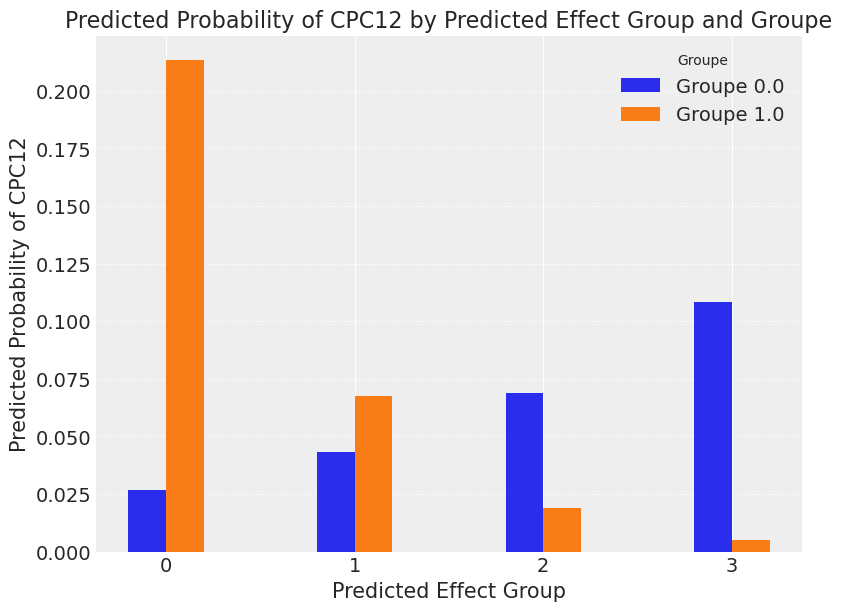

Dropped Columns: Index(['J0_TEMOIN_MASSE', 'ECG_ANOMALI', 'ECG_BAVII', 'BIO_BICARB',
       'J0_CHARLSON9', 'EI_ANTIEPILEPTIQ', 'J0_GLASGOW', 'J0_NOFLOW',
       'J0_ANTIBIO', 'J0_FIO2',
       ...
       'J0_CHARLSON10', 'SOFA_FOIE', 'SEX', 'J0_FC', 'J0_POIDS', 'J0_MYOCARD',
       'BIO_UREE', 'J0_CHARLSON12', 'EI_CONVULS', 'J0_PEP'],
      dtype='object', length=110)
Remaining Columns: Index(['J0_PAS', 'J0_VERBALE', 'J0_MOTRICE', 'J0_PUPILG', 'J0_PUPILD',
       'J0_CILIAIRE', 'J0_REFLEXCEPH', 'J0_REFLEXCARD', 'J0_CHARLSON2',
       'V0_CHARLSON15', 'V0_CHARLSON18', 'J0_ATCD', 'J0_NYHA', 'J0_IRC',
       'J0_O2', 'J0_CAUSE2_ACR', 'J0_DSA', 'J0_LOWFLOW', 'J0_ADRE',
       'V0_CHOC_AV', 'V0_CHOC_AP', 'V0_THROMBO', 'V0_CORO_ACR', 'V0_ANGIO_ACR',
       'V0_ANGIO_YES', 'J0_SEDATIF', 'J0_ADRE2', 'J0_VT', 'BIO_TP',
       'BIO_MAGNE', 'BIO_TROPO', 'BIO_PH', 'BIO_TROPO2', 'ECG_QTC',
       'ECG_SOUS_ST', 'ECG_BAVI', 'ECG_BAVIII', 'ECG_BBG', 'ECG_BBD',
       'ECG_FIBRIL', 'ECG_FLUTER', 'ECG

In [252]:
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(X_train, y_train, myBestKMeans)
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)
print(f'Dropped Columns: {myDroppedColumns}')
print(f'Remaining Columns: {myRemainingColumns}')
print(f'Num Dropped Columns: {myNumDroppedColumns}')

Optimization terminated successfully.
         Current function value: 0.313406
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.304931
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 1.5255443494543428
p-value: 0.21678239213159947
Degress of freedom: 1.0


C:\Users\mbranda1\AppData\Local\Temp\ipykernel_10440\3359315840.py:75: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


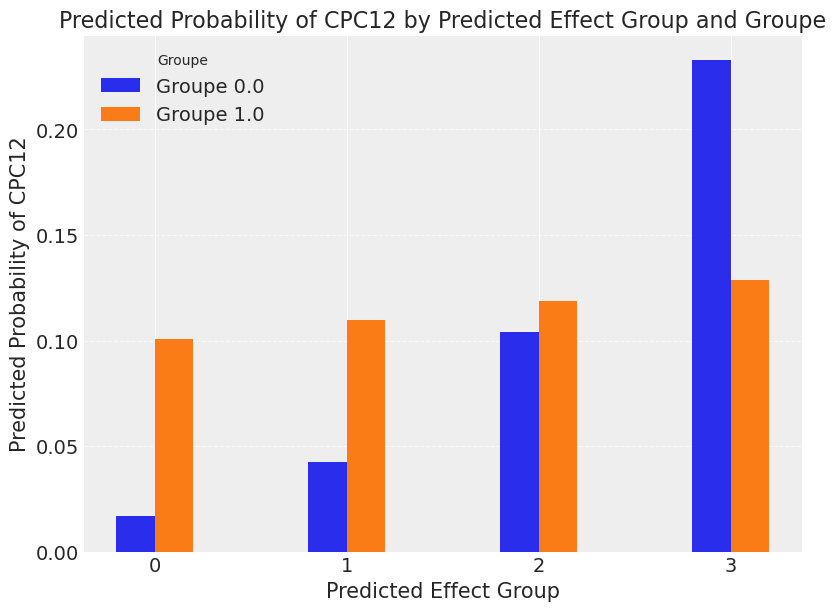

Number of Clusters: 4
Dropped Columns: Index(['J0_TEMOIN_MASSE', 'ECG_ANOMALI', 'ECG_BAVII', 'BIO_BICARB',
       'J0_CHARLSON9', 'EI_ANTIEPILEPTIQ', 'J0_GLASGOW', 'J0_NOFLOW',
       'J0_ANTIBIO', 'J0_FIO2',
       ...
       'J0_CHARLSON10', 'SOFA_FOIE', 'SEX', 'J0_FC', 'J0_POIDS', 'J0_MYOCARD',
       'BIO_UREE', 'J0_CHARLSON12', 'EI_CONVULS', 'J0_PEP'],
      dtype='object', length=110)
Remaining Columns: Index(['J0_PAS', 'J0_VERBALE', 'J0_MOTRICE', 'J0_PUPILG', 'J0_PUPILD',
       'J0_CILIAIRE', 'J0_REFLEXCEPH', 'J0_REFLEXCARD', 'J0_CHARLSON2',
       'V0_CHARLSON15', 'V0_CHARLSON18', 'J0_ATCD', 'J0_NYHA', 'J0_IRC',
       'J0_O2', 'J0_CAUSE2_ACR', 'J0_DSA', 'J0_LOWFLOW', 'J0_ADRE',
       'V0_CHOC_AV', 'V0_CHOC_AP', 'V0_THROMBO', 'V0_CORO_ACR', 'V0_ANGIO_ACR',
       'V0_ANGIO_YES', 'J0_SEDATIF', 'J0_ADRE2', 'J0_VT', 'BIO_TP',
       'BIO_MAGNE', 'BIO_TROPO', 'BIO_PH', 'BIO_TROPO2', 'ECG_QTC',
       'ECG_SOUS_ST', 'ECG_BAVI', 'ECG_BAVIII', 'ECG_BBG', 'ECG_BBD',
       'ECG_FIBRI

In [253]:
p_value, myModel, myData= getTreatmentEffectDiffUnsupervised(X_test, y_test, myBestKMeans)
plotPredictedEffectDiff(aData = myData, aBestModel = myModel)
print(f'Number of Clusters: {myBestKMeans.named_steps.clf.n_clusters}')
print(f'Dropped Columns: {myDroppedColumns}')
print(f'Remaining Columns: {myRemainingColumns}')
print(f'Num Dropped Columns: {myNumDroppedColumns}')

In [242]:
myPipeline.named_steps.preprocessor.fit_transform(X_train).toarray()

array([[ 0.21766084, -0.81704348,  0.21240059, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.77174129, -0.28515817,  0.21240059, ...,  0.        ,
         0.        ,  1.        ],
       [-1.23281425, -0.1787811 ,  0.71832698, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.73568765,  1.52325191, -0.54648901, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.68388497,  0.35310421,  0.71832698, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.09830643, -0.49791229,  0.21240059, ...,  0.        ,
         0.        ,  1.        ]])